### Loading necessary libraries/packages

In [12]:
import ants
import numpy as np
import pandas as pd


In [2]:
# img_mni = ants.image_read(ants.get_data('mni')).resample_image((256,256, 256),1,0)
# img_mni = img_mni.reorient_image2()
# print(img_mni)

## Image information
### image IO
Importnat information

Dimensions, voxe spacing, origin, orientation

ANTsImage
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 256)
	 Spacing    : (1.0, 1.0)
	 Origin     : (0.0, 0.0)
	 Direction  : [1. 0. 0. 1.]



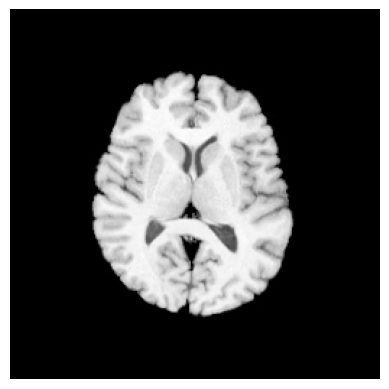

In [3]:
img_1 = ants.image_read(ants.get_data('r16'))
print(img_1)
img_1.plot()

ANTsImage
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 256)
	 Spacing    : (1.0, 1.0)
	 Origin     : (0.0, 0.0)
	 Direction  : [1. 0. 0. 1.]



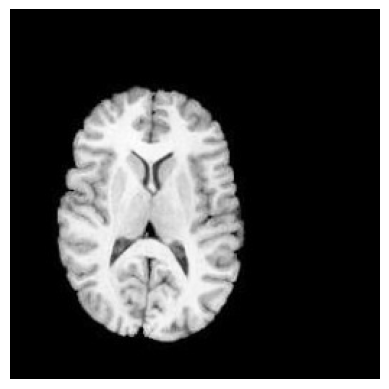

In [4]:
img_2 = ants.image_read(ants.get_data('r64'))
print(img_2)
img_2.plot()

In [5]:
img_62 = ants.image_read(ants.get_data('r62'))
img_62

ANTsImage
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 256)
	 Spacing    : (1.0, 1.0)
	 Origin     : (0.0, 0.0)
	 Direction  : [1. 0. 0. 1.]

## Status before registation


#### Resampling during registration

Parameters:

image (ANTsImage) – input image

resample_params (tuple/list) – vector of size dimension with numeric values

use_voxels (boolean) – True means interpret resample params as voxel counts

interp_type (python:integer) – one of 0 (linear), 1 (nearest neighbor), 2
(gaussian), 3 (windowed sinc), 4 (bspline)

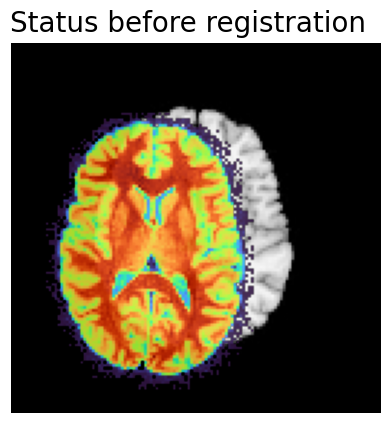

In [9]:
template_img = ants.image_read( ants.get_ants_data('r16')).resample_image((128,128),use_voxels = True, interp_type = 1)
registering_img = ants.image_read( ants.get_ants_data('r64') ).resample_image((128,128),use_voxels = True, interp_type = 1)
template_img.plot(overlay=registering_img, title='Status before registration')

## Status after registration
Type of registraion can be "Rigid", "Affine", “SyN”(Symmetric normalization: Affine + deformable transformation,with mutual information as optimization metric), etc.,


{'warpedmovout': ANTsImage
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (128, 128)
	 Spacing    : (2.0079, 2.0079)
	 Origin     : (0.0, 0.0)
	 Direction  : [1. 0. 0. 1.]
, 'warpedfixout': ANTsImage
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (128, 128)
	 Spacing    : (2.0079, 2.0079)
	 Origin     : (0.0, 0.0)
	 Direction  : [1. 0. 0. 1.]
, 'fwdtransforms': ['/tmp/tmpkdtq9tqf1Warp.nii.gz', '/tmp/tmpkdtq9tqf0GenericAffine.mat'], 'invtransforms': ['/tmp/tmpkdtq9tqf0GenericAffine.mat', '/tmp/tmpkdtq9tqf1InverseWarp.nii.gz']}


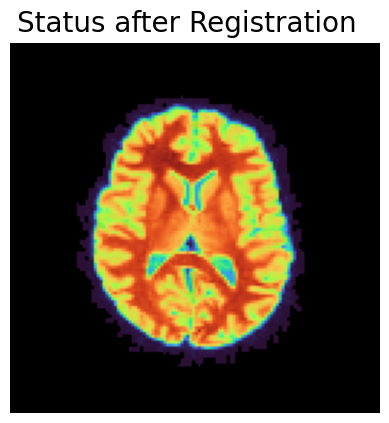

In [10]:
reg_matrix_info = ants.registration(fixed=template_img , moving=registering_img, type_of_transform='SyN')
print(reg_matrix_info)
warped_registering = reg_matrix_info['warpedmovout']
template_img.plot(overlay=warped_registering,
           title='Status after Registration')

### Using transformation output of the registration process
We can apply the transformation outputs from the registration process directly to the image.

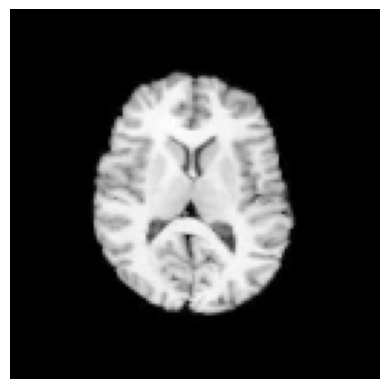

In [11]:
mywarped_registering_img = ants.apply_transforms(fixed=template_img, moving=registering_img,
                                      transformlist=reg_matrix_info['fwdtransforms'])

mywarped_registering_img.plot()